In [1]:
"""
Final Compare: Wilcoxon batch + ANOVA/Tukey + anova_test pipeline.
"""

from __future__ import annotations

from importlib import reload
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

import statistics_things.wilcoxon_curve_compare as _wcc
reload(_wcc)
from statistics_things.wilcoxon_curve_compare import (
    align_eer_dicts,
    collect_eer_by_n,
    load_json,
)

import statistics_things.anova_tukey_compare as _atc
reload(_atc)
from statistics_things.anova_tukey_compare import anova_tukey_compare

import statistics_things.anova_test_compare as _atest
reload(_atest)
from statistics_things.anova_test_compare import anova_test_compare


In [2]:
def _label_from_path(path: str | Path) -> str:
    p = Path(path)
    name = p.name if p.is_dir() else p.parent.name
    return name.removeprefix("per-user")


def batch_pairwise_wilcoxon(
    representations: dict[str, str | Path] | list[str | Path],
    n_targets: int | list[int] = 1,
    alpha: float = 0.1,
):
    """
    For each representation X: compare X vs each of the remaining ones.
    Find X that is significant against ALL remaining representations.

    Returns
    -------
    detail_df   : rows = (Focal, vs other) with p / Significant
    summary_df  : one row per Focal — Significant_vs = k/5, All_significant
    winners_df  : Focal where All_significant is True (may be empty)
    """
    if isinstance(representations, list):
        representations = {_label_from_path(p): p for p in representations}
    if isinstance(n_targets, int):
        n_targets = [n_targets]

    labels = list(representations.keys())
    if len(labels) < 2:
        raise ValueError("Need at least 2 representations")

    loaded = {lab: load_json(path) for lab, path in representations.items()}

    p_map: dict[tuple[int, str, str], float] = {}
    sig_map: dict[tuple[int, str, str], bool] = {}
    mean_map: dict[tuple[int, str], float] = {}
    users_map: dict[tuple[int, str, str], int] = {}

    for n in n_targets:
        eer_by_label = {
            lab: collect_eer_by_n(data, n) for lab, data in loaded.items()
        }
        for lab in labels:
            vals = list(eer_by_label[lab].values())
            mean_map[(n, lab)] = float(np.mean(vals)) if vals else float("nan")

        for lab_a, lab_b in combinations(labels, 2):
            common, ea, eb = align_eer_dicts(
                eer_by_label[lab_a], eer_by_label[lab_b]
            )
            if len(common) < 2:
                p_val, significant = float("nan"), False
            else:
                vec_a = np.array([ea[u] for u in common])
                vec_b = np.array([eb[u] for u in common])
                _, p_val = wilcoxon(vec_a, vec_b)
                p_val = float(p_val)
                significant = bool(p_val <= alpha)

            for x, y in ((lab_a, lab_b), (lab_b, lab_a)):
                p_map[(n, x, y)] = p_val
                sig_map[(n, x, y)] = significant
                users_map[(n, x, y)] = len(common)

    detail_rows = []
    summary_rows = []
    n_others = len(labels) - 1

    for n in n_targets:
        for focal in labels:
            others = [o for o in labels if o != focal]
            n_sig = 0
            for other in others:
                sig = sig_map[(n, focal, other)]
                if sig:
                    n_sig += 1
                detail_rows.append(
                    {
                        "n": n,
                        "Focal": focal,
                        "vs": other,
                        "Users": users_map[(n, focal, other)],
                        "Mean EER Focal (%)": round(mean_map[(n, focal)] * 100, 2),
                        "Mean EER Other (%)": round(mean_map[(n, other)] * 100, 2),
                        "p-value": p_map[(n, focal, other)],
                        "Significant": sig,
                    }
                )

            summary_rows.append(
                {
                    "n": n,
                    "Representation": focal,
                    "Mean EER (%)": round(mean_map[(n, focal)] * 100, 2),
                    "Significant_vs": f"{n_sig}/{n_others}",
                    "All_significant": n_sig == n_others,
                    "Fail_vs": ", ".join(
                        o for o in others if not sig_map[(n, focal, o)]
                    )
                    or "-",
                }
            )

    detail_df = pd.DataFrame(detail_rows)
    summary_df = (
        pd.DataFrame(summary_rows)
        .sort_values(
            ["n", "All_significant", "Mean EER (%)"],
            ascending=[True, False, True],
        )
        .reset_index(drop=True)
    )
    winners_df = summary_df[summary_df["All_significant"]].reset_index(drop=True)
    return detail_df, summary_df, winners_df


In [3]:
# Auto-collect all per-user* under Results_uc/DFL/CNN
base = Path(r"Results_uc/DFL/CNN")
reps = {
    d.name.removeprefix("per-user"): d
    for d in sorted(base.glob("per-user*"))
    if d.is_dir()
}
print("Representations:", list(reps.keys()))

detail_df, summary_df, winners_df = batch_pairwise_wilcoxon(
    reps,
    n_targets=1,
    alpha=0.1,
)

print("=== Each Representation vs. Every Other Representation ===")

display(detail_df)

print("=== Summary: Significant_vs = Number of Significant Comparisons / Total Comparisons; All_significant = Significant Against All Other Representations ===")

display(summary_df)

print("=== Winners (Significantly Different from All Other Representations) ===")

if winners_df.empty:
    print("None: No representation is significantly different from all other representations.")
else:
    display(winners_df)


Representations: ['PairWise', 'PairWise_velocity', 'PairWise_vxvy', 'XYPlot', 'XYPlot_velocity', 'XYPlot_vxvy']
=== Each Representation vs. Every Other Representation ===


,n,Focal,vs,Users,Mean EER Focal (%),Mean EER Other (%),p-value,Significant
0,1,PairWise,PairWise_velocity,21,1.15,0.59,0.001600,True
1,1,PairWise,PairWise_vxvy,21,1.15,0.84,0.045993,True
2,1,PairWise,XYPlot,21,1.15,0.82,0.026331,True
3,1,PairWise,XYPlot_velocity,21,1.15,0.76,0.031919,True
4,1,PairWise,XYPlot_vxvy,21,1.15,0.81,0.050192,True
5,1,PairWise_velocity,PairWise,21,0.59,1.15,0.001600,True
6,1,PairWise_velocity,PairWise_vxvy,21,0.59,0.84,0.038438,True
7,1,PairWise_velocity,XYPlot,21,0.59,0.82,0.050192,True
8,1,PairWise_velocity,XYPlot_velocity,21,0.59,0.76,0.111058,False
9,1,PairWise_velocity,XYPlot_vxvy,21,0.59,0.81,0.095799,True


=== Summary: Significant_vs = Number of Significant Comparisons / Total Comparisons; All_significant = Significant Against All Other Representations ===


,n,Representation,Mean EER (%),Significant_vs,All_significant,Fail_vs
0,1,PairWise,1.15,5/5,True,-
1,1,PairWise_velocity,0.59,4/5,False,XYPlot_velocity
2,1,XYPlot_velocity,0.76,2/5,False,"PairWise_velocity, PairWise_vxvy, XYPlot_vxvy"
3,1,XYPlot_vxvy,0.81,3/5,False,"PairWise_vxvy, XYPlot_velocity"
4,1,XYPlot,0.82,4/5,False,PairWise_vxvy
5,1,PairWise_vxvy,0.84,2/5,False,"XYPlot, XYPlot_velocity, XYPlot_vxvy"


=== Winners (Significantly Different from All Other Representations) ===


,n,Representation,Mean EER (%),Significant_vs,All_significant,Fail_vs
0,1,PairWise,1.15,5/5,True,-


Representations: ['PairWise+Chunk', 'PairWise_velocity', 'PairWise_vxvy', 'XYPlot', 'XYPlot_velocity', 'XYPlot_vxvy']
n=1 | users=28 | alpha=0.05
Mean EER:
  PairWise+Chunk: 13.7206%
  PairWise_velocity: 10.4038%
  PairWise_vxvy: 10.3205%
  XYPlot: 29.2864%
  XYPlot_velocity: 13.5693%
  XYPlot_vxvy: 16.5599%

=== Repeated-measures ANOVA ===
                   F Value  Num DF  Den DF        Pr > F
Representation  175.282283     5.0   135.0  3.201102e-57

ANOVA p = 3.2011e-57  ->  significant = True

=== Tukey's HSD (all pairs) ===
           group1            group2   meandiff       p-adj      lower      upper  reject
   PairWise+Chunk PairWise_velocity  -3.316794   0.0753622  -6.824032   0.190444   False
   PairWise+Chunk     PairWise_vxvy  -3.400075    0.063194  -6.907313   0.107163   False
   PairWise+Chunk            XYPlot  15.565783 6.30607e-14  12.058545  19.073021    True
   PairWise+Chunk   XYPlot_velocity  -0.151334    0.999996  -3.658572   3.355904   False
   PairWise+Chunk  

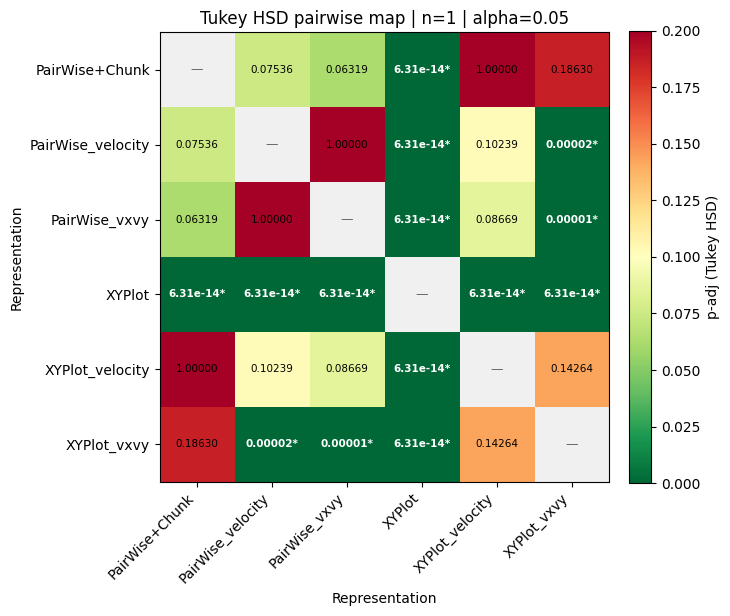

ANOVA significant: True | p = 3.2011015620524985e-57


,group1,group2,meandiff,p-adj,lower,upper,reject
0,PairWise+Chunk,PairWise_velocity,-3.316794,7.536219e-02,-6.824032,0.190444,False
1,PairWise+Chunk,PairWise_vxvy,-3.400075,6.319400e-02,-6.907313,0.107163,False
2,PairWise+Chunk,XYPlot,15.565783,6.306067e-14,12.058545,19.073021,True
3,PairWise+Chunk,XYPlot_velocity,-0.151334,9.999958e-01,-3.658572,3.355904,False
4,PairWise+Chunk,XYPlot_vxvy,2.839309,1.862996e-01,-0.667929,6.346547,False
5,PairWise_velocity,PairWise_vxvy,-0.083281,9.999998e-01,-3.590519,3.423956,False
6,PairWise_velocity,XYPlot,18.882577,6.306067e-14,15.375339,22.389815,True
7,PairWise_velocity,XYPlot_velocity,3.165460,1.023862e-01,-0.341778,6.672698,False
8,PairWise_velocity,XYPlot_vxvy,6.156103,1.636561e-05,2.648865,9.663340,True
9,PairWise_vxvy,XYPlot,18.965859,6.306067e-14,15.458621,22.473096,True


,Representation,Mean EER,Significant_vs,All_significant,Min p vs others,Max p vs others,Fail_vs
0,XYPlot,29.2864,5/5,True,0.0,0.000000,-
1,PairWise_vxvy,10.3205,2/5,False,0.0,1.000000,"PairWise+Chunk, PairWise_velocity, XYPlot_velo..."
2,PairWise_velocity,10.4038,2/5,False,0.0,1.000000,"PairWise+Chunk, PairWise_vxvy, XYPlot_velocity"
3,XYPlot_velocity,13.5693,1/5,False,0.0,0.999996,"PairWise+Chunk, PairWise_velocity, PairWise_vx..."
4,PairWise+Chunk,13.7206,1/5,False,0.0,0.999996,"PairWise_velocity, PairWise_vxvy, XYPlot_veloc..."
5,XYPlot_vxvy,16.5599,3/5,False,0.0,0.186300,"PairWise+Chunk, XYPlot_velocity"


,PairWise+Chunk,PairWise_velocity,PairWise_vxvy,XYPlot,XYPlot_velocity,XYPlot_vxvy
PairWise+Chunk,NaN,7.536219e-02,6.319400e-02,6.306067e-14,9.999958e-01,1.862996e-01
PairWise_velocity,7.536219e-02,NaN,9.999998e-01,6.306067e-14,1.023862e-01,1.636561e-05
PairWise_vxvy,6.319400e-02,9.999998e-01,NaN,6.306067e-14,8.668624e-02,1.200687e-05
XYPlot,6.306067e-14,6.306067e-14,6.306067e-14,NaN,6.306067e-14,6.306067e-14
XYPlot_velocity,9.999958e-01,1.023862e-01,8.668624e-02,6.306067e-14,NaN,1.426439e-01
XYPlot_vxvy,1.862996e-01,1.636561e-05,1.200687e-05,6.306067e-14,1.426439e-01,NaN


In [4]:
# ANOVA + Tukey HSD (email workflow)
base = Path(r"Results/ChaoShen/ViT")
reps = {
    d.name.removeprefix("per-user"): d
    for d in sorted(base.glob("per-user*"))
    if d.is_dir()
}
print("Representations:", list(reps.keys()))

res = anova_tukey_compare(
    reps,
    n=1,
    alpha=0.05,
    plot=True,
)

print("ANOVA significant:", res["anova_significant"], "| p =", res["anova_p"])
if res["anova_significant"]:
    display(res["tukey_df"])
    display(res["per_rep_summary"])
    display(res["p_matrix"])


Loaded 6 representations from Results_uc/TWOS/ViT
  ['PairWise', 'PairWise_velocity', 'PairWise_vxvy', 'XYPlot', 'XYPlot_velocity', 'XYPlot_vxvy']
n=1 | users=24 | alpha=0.05
Mean EER:
  PairWise: 14.6259%
  PairWise_velocity: 7.6339%
  PairWise_vxvy: 5.4167%
  XYPlot: 7.9078%
  XYPlot_velocity: 6.3212%
  XYPlot_vxvy: 7.6936%

=== Shapiro-Wilk (pairwise within-user differences) ===
  PairWise - PairWise_velocity: W=0.960, p=0.4289, NORMAL
  PairWise - PairWise_vxvy: W=0.911, p=0.03785, NOT NORMAL
  PairWise - XYPlot: W=0.948, p=0.2501, NORMAL
  PairWise - XYPlot_velocity: W=0.948, p=0.2461, NORMAL
  PairWise - XYPlot_vxvy: W=0.968, p=0.6188, NORMAL
  PairWise_velocity - PairWise_vxvy: W=0.487, p=4.265e-08, NOT NORMAL
  PairWise_velocity - XYPlot: W=0.840, p=0.001421, NOT NORMAL
  PairWise_velocity - XYPlot_velocity: W=0.817, p=0.0005717, NOT NORMAL
  PairWise_velocity - XYPlot_vxvy: W=0.881, p=0.008699, NOT NORMAL
  PairWise_vxvy - XYPlot: W=0.968, p=0.6135, NORMAL
  PairWise_vxvy - XY

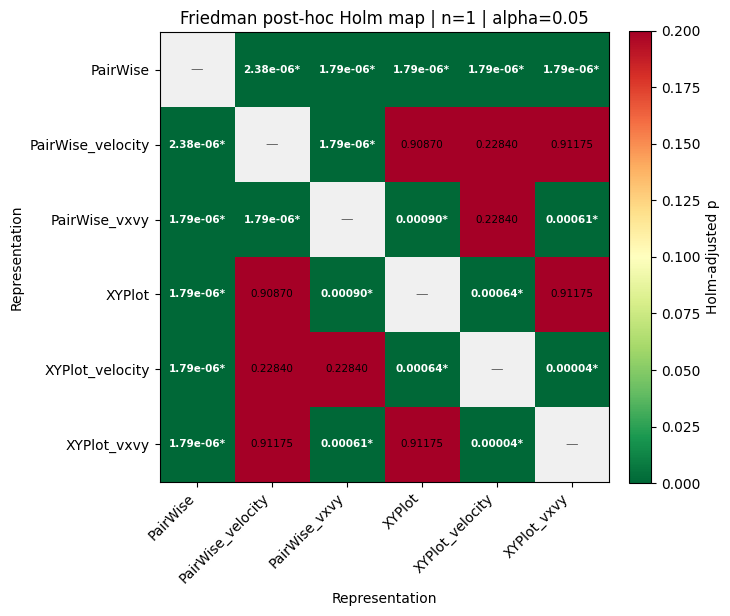

method: friedman_wilcoxon_holm
omnibus: Friedman p = 1.4533038702282804e-14
n reps: 6


,A,B,W,p_unc,p_corr,Significant
0,PairWise,PairWise_velocity,1.0,2.384186e-07,0.000002,True
1,PairWise,PairWise_vxvy,0.0,1.192093e-07,0.000002,True
2,PairWise,XYPlot,0.0,1.192093e-07,0.000002,True
3,PairWise,XYPlot_velocity,0.0,1.192093e-07,0.000002,True
4,PairWise,XYPlot_vxvy,0.0,1.192093e-07,0.000002,True
5,PairWise_velocity,PairWise_vxvy,0.0,1.192093e-07,0.000002,True
6,PairWise_velocity,XYPlot,113.0,3.028992e-01,0.908698,False
7,PairWise_velocity,XYPlot_velocity,81.0,4.906118e-02,0.228398,False
8,PairWise_velocity,XYPlot_vxvy,133.0,6.431422e-01,0.911749,False
9,PairWise_vxvy,XYPlot,27.0,1.496077e-04,0.000898,True


,Representation,Mean EER,Significant_vs,All_significant,Fail_vs
0,PairWise,14.6259,5/5,True,-
1,PairWise_vxvy,5.4167,4/5,False,XYPlot_velocity
2,XYPlot_velocity,6.3212,3/5,False,"PairWise_velocity, PairWise_vxvy"
3,PairWise_velocity,7.6339,2/5,False,"XYPlot, XYPlot_velocity, XYPlot_vxvy"
4,XYPlot_vxvy,7.6936,3/5,False,"PairWise_velocity, XYPlot"
5,XYPlot,7.9078,3/5,False,"PairWise_velocity, XYPlot_vxvy"


,PairWise,PairWise_velocity,PairWise_vxvy,XYPlot,XYPlot_velocity,XYPlot_vxvy
PairWise,NaN,0.000002,0.000002,0.000002,0.000002,0.000002
PairWise_velocity,0.000002,NaN,0.000002,0.908698,0.228398,0.911749
PairWise_vxvy,0.000002,0.000002,NaN,0.000898,0.228398,0.000610
XYPlot,0.000002,0.908698,0.000898,NaN,0.000636,0.911749
XYPlot_velocity,0.000002,0.228398,0.228398,0.000636,NaN,0.000035
XYPlot_vxvy,0.000002,0.911749,0.000610,0.911749,0.000035,NaN


In [5]:
# === anova_test.py pipeline: ONE link, all per-user* (typically 6) ===
# Shapiro -> Friedman+Wilcoxon+Holm  OR  RM-ANOVA+paired t+Holm

res6 = anova_test_compare(
    base=r"Results_uc/TWOS/ViT",  # change this one path
    n=1,
    alpha=0.05,
    plot=True,
)

print("method:", res6["method"])
print("omnibus:", res6["omnibus_name"], "p =", res6["omnibus_p"])
print("n reps:", len(res6["labels"]))
display(res6["pairwise_df"])
display(res6["per_rep_summary"])
display(res6["p_matrix"])


Loaded 12 representations (LA=6, LF=6)
  LA: ['LA:PairWise', 'LA:PairWise_velocity', 'LA:PairWise_vxvy', 'LA:XYPlot', 'LA:XYPlot_velocity', 'LA:XYPlot_vxvy']
  LF: ['LF:PairWise', 'LF:PairWise_velocity', 'LF:PairWise_vxvy', 'LF:XYPlot', 'LF:XYPlot_velocity', 'LF:XYPlot_vxvy']
n=1 | users=24 | alpha=0.05
Mean EER:
  LA:PairWise: 14.6259%
  LA:PairWise_velocity: 7.6339%
  LA:PairWise_vxvy: 5.4167%
  LA:XYPlot: 7.9078%
  LA:XYPlot_velocity: 6.3212%
  LA:XYPlot_vxvy: 7.6936%
  LF:PairWise: 17.2896%
  LF:PairWise_velocity: 14.9832%
  LF:PairWise_vxvy: 14.8750%
  LF:XYPlot: 25.7598%
  LF:XYPlot_velocity: 16.4890%
  LF:XYPlot_vxvy: 22.2801%

=== Shapiro-Wilk (pairwise within-user differences) ===
  LA:PairWise - LA:PairWise_velocity: W=0.960, p=0.4289, NORMAL
  LA:PairWise - LA:PairWise_vxvy: W=0.911, p=0.03785, NOT NORMAL
  LA:PairWise - LA:XYPlot: W=0.948, p=0.2501, NORMAL
  LA:PairWise - LA:XYPlot_velocity: W=0.948, p=0.2461, NORMAL
  LA:PairWise - LA:XYPlot_vxvy: W=0.968, p=0.6188, NORMAL

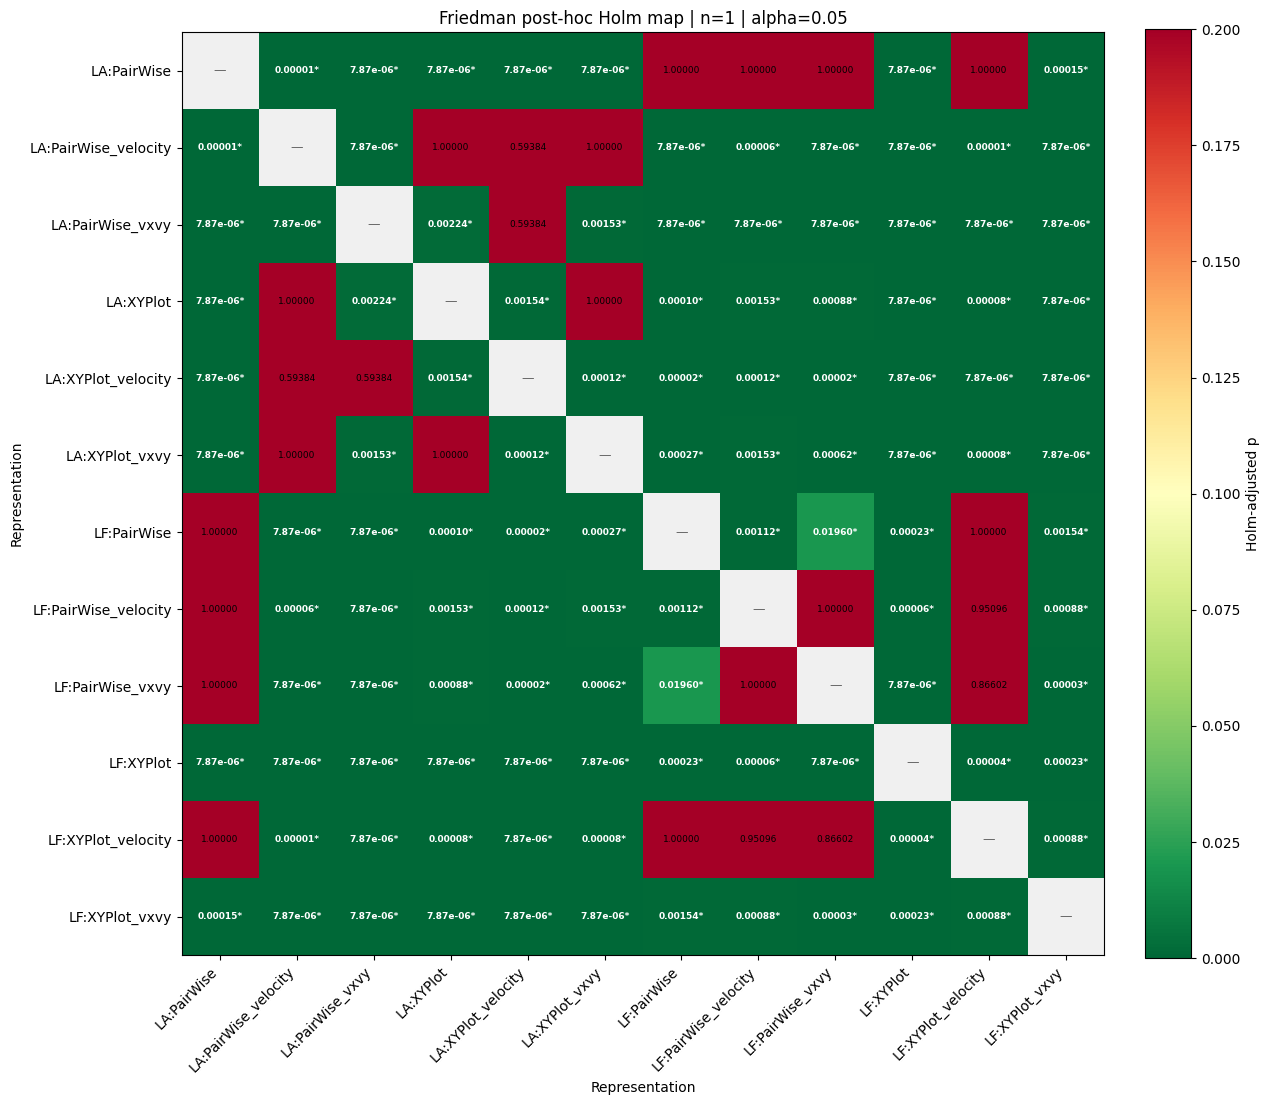

method: friedman_wilcoxon_holm
omnibus: Friedman p = 9.22580137079168e-39
n reps: 12


,A,B,W,p_unc,p_corr,Significant
0,LA:PairWise,LA:PairWise_velocity,1.0,2.384186e-07,0.000010,True
1,LA:PairWise,LA:PairWise_vxvy,0.0,1.192093e-07,0.000008,True
2,LA:PairWise,LA:XYPlot,0.0,1.192093e-07,0.000008,True
3,LA:PairWise,LA:XYPlot_velocity,0.0,1.192093e-07,0.000008,True
4,LA:PairWise,LA:XYPlot_vxvy,0.0,1.192093e-07,0.000008,True
...,...,...,...,...,...,...
61,LF:PairWise_vxvy,LF:XYPlot_velocity,88.0,7.872927e-02,0.866022,False
62,LF:PairWise_vxvy,LF:XYPlot_vxvy,4.0,8.344650e-07,0.000032,True
63,LF:XYPlot,LF:XYPlot_velocity,5.0,1.192093e-06,0.000044,True
64,LF:XYPlot,LF:XYPlot_vxvy,12.0,8.344650e-06,0.000234,True


,Representation,Mean EER,Significant_vs,All_significant,Fail_vs
0,LF:XYPlot_vxvy,22.2801,11/11,True,-
1,LF:XYPlot,25.7598,11/11,True,-
2,LA:PairWise_vxvy,5.4167,10/11,False,LA:XYPlot_velocity
3,LA:XYPlot_velocity,6.3212,9/11,False,"LA:PairWise_velocity, LA:PairWise_vxvy"
4,LA:PairWise_velocity,7.6339,8/11,False,"LA:XYPlot, LA:XYPlot_velocity, LA:XYPlot_vxvy"
5,LA:XYPlot_vxvy,7.6936,9/11,False,"LA:PairWise_velocity, LA:XYPlot"
6,LA:XYPlot,7.9078,9/11,False,"LA:PairWise_velocity, LA:XYPlot_vxvy"
7,LA:PairWise,14.6259,7/11,False,"LF:PairWise, LF:PairWise_velocity, LF:PairWise..."
8,LF:PairWise_vxvy,14.8750,8/11,False,"LA:PairWise, LF:PairWise_velocity, LF:XYPlot_v..."
9,LF:PairWise_velocity,14.9832,8/11,False,"LA:PairWise, LF:PairWise_vxvy, LF:XYPlot_velocity"


,LA:PairWise,LA:PairWise_velocity,LA:PairWise_vxvy,LA:XYPlot,LA:XYPlot_velocity,LA:XYPlot_vxvy,LF:PairWise,LF:PairWise_velocity,LF:PairWise_vxvy,LF:XYPlot,LF:XYPlot_velocity,LF:XYPlot_vxvy
LA:PairWise,NaN,0.000010,0.000008,0.000008,0.000008,0.000008,1.000000,1.000000,1.000000,0.000008,1.000000,0.000149
LA:PairWise_velocity,0.000010,NaN,0.000008,1.000000,0.593836,1.000000,0.000008,0.000060,0.000008,0.000008,0.000010,0.000008
LA:PairWise_vxvy,0.000008,0.000008,NaN,0.002244,0.593836,0.001526,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008
LA:XYPlot,0.000008,1.000000,0.002244,NaN,0.001544,1.000000,0.000095,0.001526,0.000878,0.000008,0.000077,0.000008
LA:XYPlot_velocity,0.000008,0.593836,0.593836,0.001544,NaN,0.000122,0.000024,0.000122,0.000024,0.000008,0.000008,0.000008
LA:XYPlot_vxvy,0.000008,1.000000,0.001526,1.000000,0.000122,NaN,0.000273,0.001526,0.000617,0.000008,0.000077,0.000008
LF:PairWise,1.000000,0.000008,0.000008,0.000095,0.000024,0.000273,NaN,0.001119,0.019597,0.000234,1.000000,0.001544
LF:PairWise_velocity,1.000000,0.000060,0.000008,0.001526,0.000122,0.001526,0.001119,NaN,1.000000,0.000060,0.950960,0.000878
LF:PairWise_vxvy,1.000000,0.000008,0.000008,0.000878,0.000024,0.000617,0.019597,1.000000,NaN,0.000008,0.866022,0.000032
LF:XYPlot,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000234,0.000060,0.000008,NaN,0.000044,0.000234


In [6]:
# === anova_test.py pipeline: 12 reps = LA(Results_uc) + LF(Results) ===
# Shapiro -> Friedman+Wilcoxon+Holm  OR  RM-ANOVA+paired t+Holm

res = anova_test_compare(
    location_aware_base=r"Results_uc/TWOS/ViT",   # 6 per-user, tag LA
    location_free_base=r"Results/TWOS/ViT",       # 6 per-user, tag LF
    n=1,
    alpha=0.05,
    plot=True,
)

print("method:", res["method"])
print("omnibus:", res["omnibus_name"], "p =", res["omnibus_p"])
print("n reps:", len(res["labels"]))
display(res["pairwise_df"])
display(res["per_rep_summary"])
display(res["p_matrix"])


Loaded 6 representations from Results/Balabit/CNN_new/
  ['PairWise+Chunk', 'PairWise_velocity+Chunk', 'PairWise_vxvy+Chunk', 'XYPlot_c', 'XYPlot_velocity_c', 'XYPlot_vxvy_c']
[Info] Balabit numeric index -> user mapping applied for:
       XYPlot_c, XYPlot_velocity_c, XYPlot_vxvy_c
[Info] mapping (0->user7, ..., 9->user35):
  0 -> user7
  1 -> user9
  2 -> user12
  3 -> user15
  4 -> user16
  5 -> user20
  6 -> user21
  7 -> user23
  8 -> user29
  9 -> user35
[Info] paired common users (10): ['user7', 'user9', 'user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35']
n=1 | users=10 | alpha=0.05
Mean EER:
  PairWise+Chunk: 10.6108%
  PairWise_velocity+Chunk: 7.8907%
  PairWise_vxvy+Chunk: 6.6750%
  XYPlot_c: 14.8403%
  XYPlot_velocity_c: 9.6275%
  XYPlot_vxvy_c: 10.9865%

=== Shapiro-Wilk (pairwise within-user differences) ===
  PairWise+Chunk - PairWise_velocity+Chunk: W=0.981, p=0.9696, NORMAL
  PairWise+Chunk - PairWise_vxvy+Chunk: W=0.950, p=0.6708, NORMAL
  P

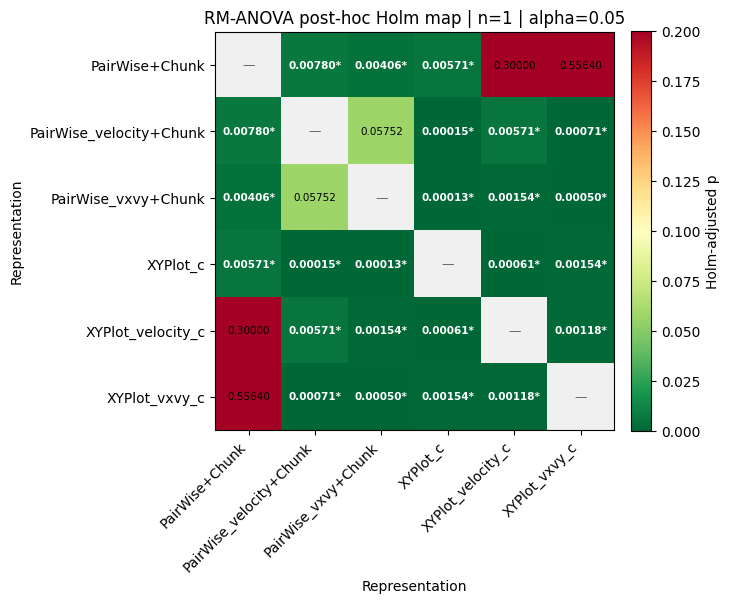

In [7]:
res6 = anova_test_compare(
    base=r"Results/Balabit/CNN_new/",
    n=1,
    alpha=0.05,
    plot=True,
)

Loaded 6 representations from Results_uc/Balabit/ViT
  ['PairWise', 'PairWise_velocity', 'PairWise_vxvy', 'XYPlot', 'XYPlot_velocity', 'XYPlot_vxvy']
[Info] Balabit numeric index -> user mapping applied for:
       PairWise, PairWise_velocity, PairWise_vxvy, XYPlot, XYPlot_velocity, XYPlot_vxvy
[Info] mapping (0->user7, ..., 9->user35):
  0 -> user7
  1 -> user9
  2 -> user12
  3 -> user15
  4 -> user16
  5 -> user20
  6 -> user21
  7 -> user23
  8 -> user29
  9 -> user35
[Info] paired common users (10): ['user7', 'user9', 'user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35']
n=1 | users=10 | alpha=0.05
Mean EER:
  PairWise: 8.9526%
  PairWise_velocity: 7.0470%
  PairWise_vxvy: 5.8050%
  XYPlot: 10.5520%
  XYPlot_velocity: 6.7236%
  XYPlot_vxvy: 7.2788%

=== Shapiro-Wilk (pairwise within-user differences) ===
  PairWise - PairWise_velocity: W=0.937, p=0.5241, NORMAL
  PairWise - PairWise_vxvy: W=0.932, p=0.469, NORMAL
  PairWise - XYPlot: W=0.864, p=0.08592, N

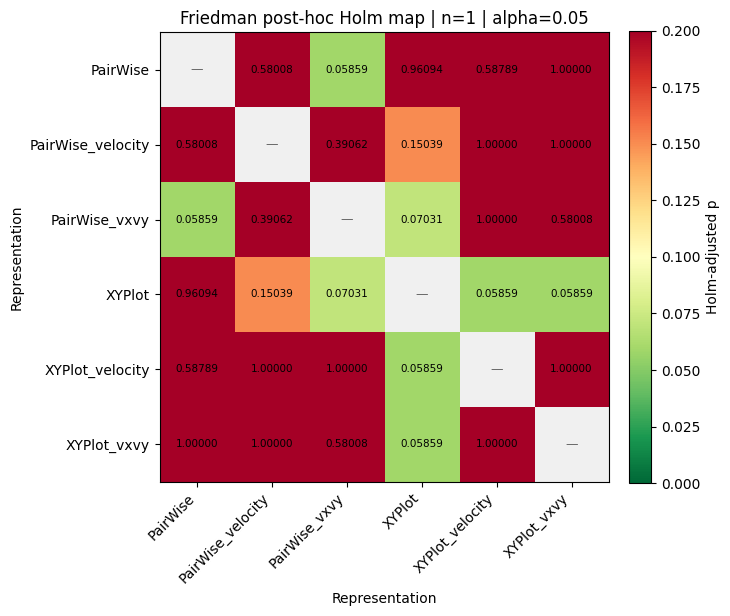

In [8]:
res6 = anova_test_compare(
    base=r"Results_uc/Balabit/ViT",
    n=1,
    alpha=0.05,
    plot=True,
)

Loaded 6 representations from Results_uc/TWOS/ViT
  ['PairWise', 'PairWise_velocity', 'PairWise_vxvy', 'XYPlot', 'XYPlot_velocity', 'XYPlot_vxvy']
n=1 | users=24 | alpha=0.05
Mean EER:
  PairWise: 14.6259%
  PairWise_velocity: 7.6339%
  PairWise_vxvy: 5.4167%
  XYPlot: 7.9078%
  XYPlot_velocity: 6.3212%
  XYPlot_vxvy: 7.6936%

=== Shapiro-Wilk (pairwise within-user differences) ===
  PairWise - PairWise_velocity: W=0.960, p=0.4289, NORMAL
  PairWise - PairWise_vxvy: W=0.911, p=0.03785, NOT NORMAL
  PairWise - XYPlot: W=0.948, p=0.2501, NORMAL
  PairWise - XYPlot_velocity: W=0.948, p=0.2461, NORMAL
  PairWise - XYPlot_vxvy: W=0.968, p=0.6188, NORMAL
  PairWise_velocity - PairWise_vxvy: W=0.487, p=4.265e-08, NOT NORMAL
  PairWise_velocity - XYPlot: W=0.840, p=0.001421, NOT NORMAL
  PairWise_velocity - XYPlot_velocity: W=0.817, p=0.0005717, NOT NORMAL
  PairWise_velocity - XYPlot_vxvy: W=0.881, p=0.008699, NOT NORMAL
  PairWise_vxvy - XYPlot: W=0.968, p=0.6135, NORMAL
  PairWise_vxvy - XY

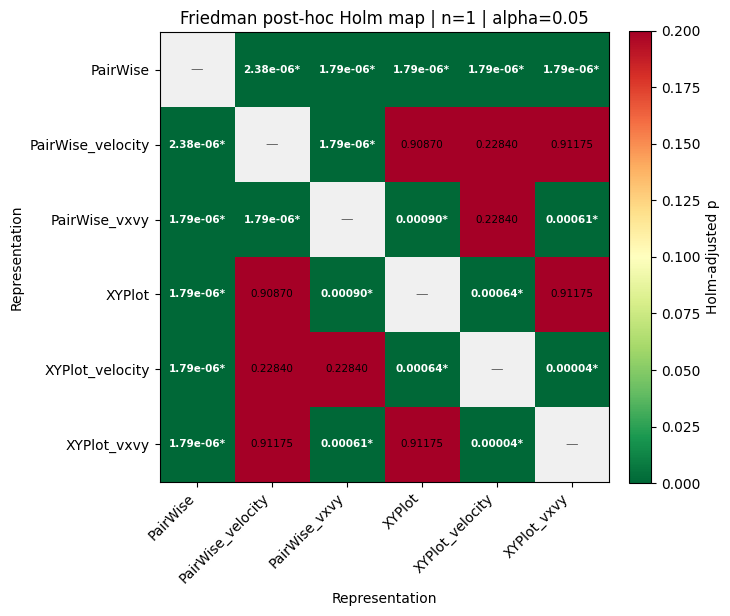

In [9]:
res6 = anova_test_compare(
    base=r"Results_uc/TWOS/ViT",
    n=1,
    alpha=0.05,
    plot=True,
)

Loaded 6 representations from Results_uc/ChaoShen/ViT/
  ['PairWise', 'PairWise_velocity', 'PairWise_vxvy', 'XYPlot', 'XYPlot_velocity', 'XYPlot_vxvy']
n=1 | users=28 | alpha=0.05
Mean EER:
  PairWise: 17.1525%
  PairWise_velocity: 7.9285%
  PairWise_vxvy: 7.5674%
  XYPlot: 17.9076%
  XYPlot_velocity: 12.2143%
  XYPlot_vxvy: 14.7892%

=== Shapiro-Wilk (pairwise within-user differences) ===
  PairWise - PairWise_velocity: W=0.878, p=0.003637, NOT NORMAL
  PairWise - PairWise_vxvy: W=0.784, p=5.686e-05, NOT NORMAL
  PairWise - XYPlot: W=0.949, p=0.1875, NORMAL
  PairWise - XYPlot_velocity: W=0.857, p=0.001327, NOT NORMAL
  PairWise - XYPlot_vxvy: W=0.871, p=0.002584, NOT NORMAL
  PairWise_velocity - PairWise_vxvy: W=0.646, p=5.335e-07, NOT NORMAL
  PairWise_velocity - XYPlot: W=0.924, p=0.04345, NOT NORMAL
  PairWise_velocity - XYPlot_velocity: W=0.936, p=0.08698, NORMAL
  PairWise_velocity - XYPlot_vxvy: W=0.921, p=0.03589, NOT NORMAL
  PairWise_vxvy - XYPlot: W=0.903, p=0.01351, NOT NO

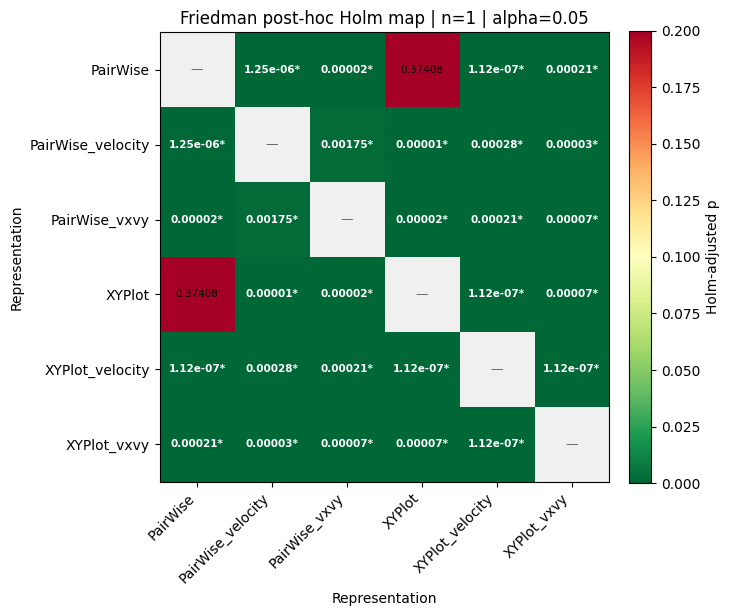

In [10]:
res6 = anova_test_compare(
    base=r"Results_uc/ChaoShen/ViT/",
    n=1,
    alpha=0.05,
    plot=True,
)

Loaded 6 representations from Results_uc/DFL/ViT
  ['PairWise', 'PairWise_velocity', 'PairWise_vxvy', 'XYPlot', 'XYPlot_velocity', 'XYPlot_vxvy']
n=1 | users=21 | alpha=0.05
Mean EER:
  PairWise: 2.6333%
  PairWise_velocity: 0.7084%
  PairWise_vxvy: 0.7994%
  XYPlot: 1.4504%
  XYPlot_velocity: 1.3747%
  XYPlot_vxvy: 1.4447%

=== Shapiro-Wilk (pairwise within-user differences) ===
  PairWise - PairWise_velocity: W=0.932, p=0.1508, NORMAL
  PairWise - PairWise_vxvy: W=0.936, p=0.1795, NORMAL
  PairWise - XYPlot: W=0.928, p=0.1228, NORMAL
  PairWise - XYPlot_velocity: W=0.961, p=0.5365, NORMAL
  PairWise - XYPlot_vxvy: W=0.921, p=0.09078, NORMAL
  PairWise_velocity - PairWise_vxvy: W=0.491, p=1.665e-07, NOT NORMAL
  PairWise_velocity - XYPlot: W=0.936, p=0.1856, NORMAL
  PairWise_velocity - XYPlot_velocity: W=0.944, p=0.2655, NORMAL
  PairWise_velocity - XYPlot_vxvy: W=0.957, p=0.4609, NORMAL
  PairWise_vxvy - XYPlot: W=0.928, p=0.1266, NORMAL
  PairWise_vxvy - XYPlot_velocity: W=0.913, p

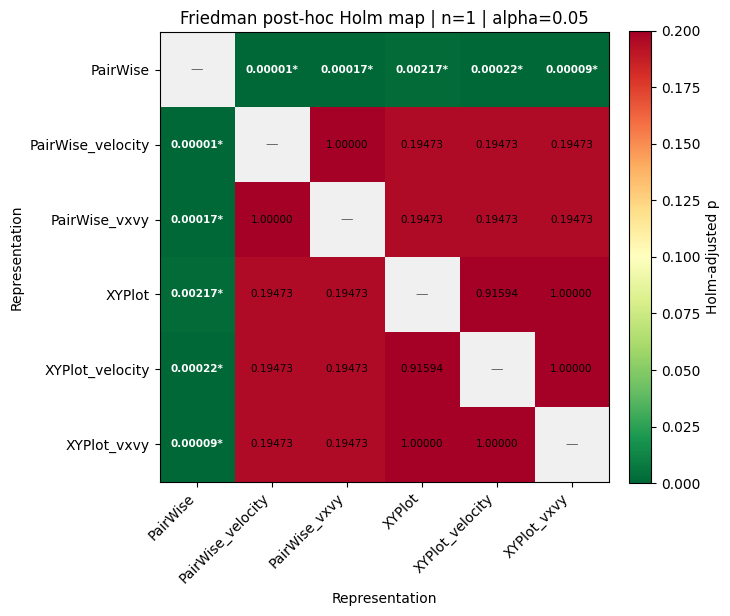

In [11]:
res6 = anova_test_compare(
    base=r"Results_uc/DFL/ViT",
    n=1,
    alpha=0.05,
    plot=True,
)